## Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

**Scenario.** An agricultural extension officer wants to compare rainfall regimes across regions and advise farmers on which months suit which crops.



This notebook uses the `Region` and `CropRule` classes, and the `cosine_similarity` function, defined in `src/project4_rainfall.py`. Crop thresholds are cited in `references/sources.txt`. This mini-project also carries the repository's one required **extension**: real NASA POWER monthly rainfall data for 2015-2024 (see the last section).

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as scipy_cosine

sys.path.insert(0, "../src")
from project4_rainfall import CropRule, Region, cosine_similarity

np.random.seed(42)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

### Task 1: Regions and basic rainfall statistics (illustrative data)

In [2]:
region_data = {
    "Kampala": [120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130],
    "Gulu": [8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15],
    "Mbarara": [70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90],
}
regions = {name: Region(name, values) for name, values in region_data.items()}

for name, region in regions.items():
    print(f"\n{name}")
    print(f"  Annual total: {region.annual_total():.0f} mm")
    print(f"  Annual mean: {region.annual_mean():.1f} mm/month")
    print(f"  Wettest month: {MONTHS[region.wettest_month()]}")
    print(f"  Driest month: {MONTHS[region.driest_month()]}")
    print(f"  Coefficient of variation: {region.coefficient_of_variation():.3f}")


Kampala
  Annual total: 1600 mm
  Annual mean: 133.3 mm/month
  Wettest month: May
  Driest month: Sep
  Coefficient of variation: 0.388

Gulu
  Annual total: 1388 mm
  Annual mean: 115.7 mm/month
  Wettest month: Aug
  Driest month: Jan
  Coefficient of variation: 0.642

Mbarara
  Annual total: 1040 mm
  Annual mean: 86.7 mm/month
  Wettest month: Apr
  Driest month: Jul
  Coefficient of variation: 0.444


### Task 2: Crop suitability rules and monthly classification

Thresholds are cited in `references/sources.txt` (simplified, illustrative monthly bands derived from general FAO crop-water guidance).

In [3]:
crop_rules = {
    "maize": CropRule("maize", min_mm=60, max_mm=180, source="FAO Crop Water Information (adapted)"),
    "beans": CropRule("beans", min_mm=60, max_mm=150, source="FAO Crop Water Information (adapted)"),
    "coffee": CropRule("coffee", min_mm=100, max_mm=250, source="FAO Crop Water Information (adapted)"),
}

suitability_table = pd.DataFrame(index=MONTHS)
for name, region in regions.items():
    for crop_name, rule in crop_rules.items():
        column = f"{name}-{crop_name}"
        suitability_table[column] = [rule.classify_month(mm) for mm in region.monthly_mm]

suitability_table

,Kampala-maize,Kampala-beans,Kampala-coffee,Gulu-maize,Gulu-beans,Gulu-coffee,Mbarara-maize,Mbarara-beans,Mbarara-coffee
Jan,Good for maize,Good for beans,Good for coffee,Drought risk,Drought risk,Drought risk,Good for maize,Good for beans,Drought risk
Feb,Good for maize,Good for beans,Good for coffee,Drought risk,Drought risk,Drought risk,Good for maize,Good for beans,Drought risk
Mar,Good for maize,Waterlogging risk,Good for coffee,Good for maize,Good for beans,Drought risk,Good for maize,Good for beans,Good for coffee
Apr,Waterlogging risk,Waterlogging risk,Good for coffee,Good for maize,Waterlogging risk,Good for coffee,Good for maize,Good for beans,Good for coffee
May,Waterlogging risk,Waterlogging risk,Good for coffee,Waterlogging risk,Waterlogging risk,Good for coffee,Good for maize,Good for beans,Drought risk
Jun,Good for maize,Waterlogging risk,Good for coffee,Good for maize,Good for beans,Good for coffee,Drought risk,Drought risk,Drought risk
Jul,Good for maize,Good for beans,Drought risk,Good for maize,Waterlogging risk,Good for coffee,Drought risk,Drought risk,Drought risk
Aug,Good for maize,Good for beans,Drought risk,Waterlogging risk,Waterlogging risk,Good for coffee,Drought risk,Drought risk,Drought risk
Sep,Good for maize,Good for beans,Drought risk,Good for maize,Waterlogging risk,Good for coffee,Good for maize,Good for beans,Good for coffee
Oct,Good for maize,Good for beans,Good for coffee,Good for maize,Good for beans,Good for coffee,Good for maize,Good for beans,Good for coffee


### Task 3: Correcting last year's cosine similarity bug

`math.cos()` computes the cosine of a single angle, not the similarity between two vectors. The correct formula is `(a . b) / (|a| * |b|)`, verified below against `scipy.spatial.distance.cosine`.

In [4]:
kampala_vec = regions["Kampala"].monthly_mm
gulu_vec = regions["Gulu"].monthly_mm

ours = cosine_similarity(kampala_vec, gulu_vec)
scipy_similarity = 1 - scipy_cosine(kampala_vec, gulu_vec)
print(f"Our cosine_similarity(Kampala, Gulu): {ours:.4f}")
print(f"1 - scipy cosine distance:            {scipy_similarity:.4f}")
print(f"Match: {np.isclose(ours, scipy_similarity)}")

Our cosine_similarity(Kampala, Gulu): 0.7866
1 - scipy cosine distance:            0.7866
Match: True


### Task 4: Similarity/distance matrices between every pair of regions

Cosine similarity compares only the *shape* of the rainfall pattern (ignoring scale), so two regions with a similar wet/dry rhythm but very different totals can still score as "similar" - this is why Euclidean distance (which does care about scale) and Pearson correlation are shown alongside it.

In [5]:
names = list(regions.keys())
cosine_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
pearson_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
euclidean_matrix = pd.DataFrame(index=names, columns=names, dtype=float)

for a in names:
    for b in names:
        vec_a, vec_b = regions[a].monthly_mm, regions[b].monthly_mm
        cosine_matrix.loc[a, b] = cosine_similarity(vec_a, vec_b)
        pearson_matrix.loc[a, b] = np.corrcoef(vec_a, vec_b)[0, 1]
        euclidean_matrix.loc[a, b] = np.linalg.norm(vec_a - vec_b)

print("Cosine similarity:\n", cosine_matrix.round(3))
print("\nPearson correlation:\n", pearson_matrix.round(3))
print("\nEuclidean distance (mm):\n", euclidean_matrix.round(1))

Cosine similarity:
          Kampala   Gulu  Mbarara
Kampala    1.000  0.787    0.891
Gulu       0.787  1.000    0.749
Mbarara    0.891  0.749    1.000

Pearson correlation:
          Kampala   Gulu  Mbarara
Kampala    1.000 -0.066    0.209
Gulu      -0.066  1.000   -0.174
Mbarara    0.209 -0.174    1.000

Euclidean distance (mm):
          Kampala   Gulu  Mbarara
Kampala      0.0  315.3    250.4
Gulu       315.3    0.0    312.8
Mbarara    250.4  312.8      0.0


### Task 5: Automatic rainy-season detection (unimodal vs bimodal)

In [6]:
for name, region in regions.items():
    label = "bimodal (two rainy seasons)" if region.is_bimodal() else "unimodal (one rainy season)"
    print(f"{name}: {label}")

print(
    "\nExpected climate pattern: Kampala (Lake Victoria basin) and Mbarara are known to be "
    "bimodal, with two rainy seasons (around Mar-May and Sep-Nov); Gulu, in northern Uganda, "
    "is known to be closer to a single long unimodal rainy season."
)

Kampala: unimodal (one rainy season)
Gulu: bimodal (two rainy seasons)
Mbarara: bimodal (two rainy seasons)

Expected climate pattern: Kampala (Lake Victoria basin) and Mbarara are known to be bimodal, with two rainy seasons (around Mar-May and Sep-Nov); Gulu, in northern Uganda, is known to be closer to a single long unimodal rainy season.


### Task 6: Visualisations - rainfall line chart and crop suitability heatmap

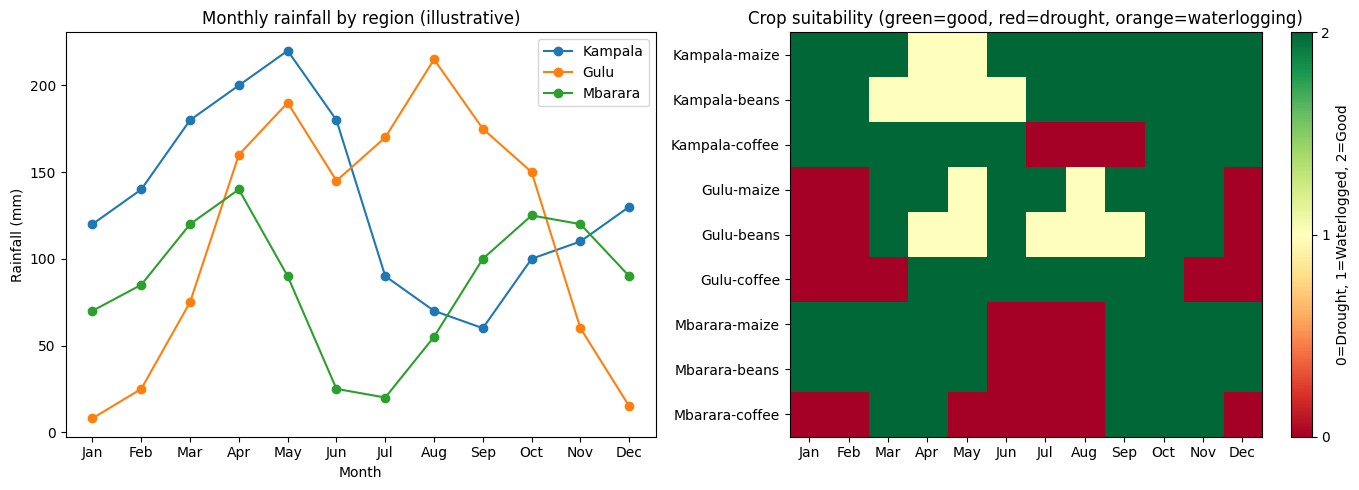

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, region in regions.items():
    ax1.plot(MONTHS, region.monthly_mm, marker="o", label=name)
ax1.set_xlabel("Month")
ax1.set_ylabel("Rainfall (mm)")
ax1.set_title("Monthly rainfall by region (illustrative)")
ax1.legend()

score_map = {"Drought risk": 0, "Waterlogging risk": 1, "Good for maize": 2, "Good for beans": 2, "Good for coffee": 2}
heat_data = suitability_table.map(lambda label: score_map[label])
im = ax2.imshow(heat_data.T, aspect="auto", cmap="RdYlGn")
ax2.set_xticks(range(12))
ax2.set_xticklabels(MONTHS)
ax2.set_yticks(range(len(heat_data.columns)))
ax2.set_yticklabels(heat_data.columns)
ax2.set_title("Crop suitability (green=good, red=drought, orange=waterlogging)")
fig.colorbar(im, ax=ax2, ticks=[0, 1, 2], label="0=Drought, 1=Waterlogged, 2=Good")

plt.tight_layout()
plt.show()

### Task 7: Advisory note for farmers (Gulu, <=200 words)

Gulu shows a single long wet season running from around April through October, with a short dry spell from December to February (driest: January, 8 mm). Based on the crop suitability table above, **maize** is a strong fit for Gulu: April-June and August-October fall in the "good for maize" band (60-180 mm/month), giving two realistic planting windows - a first-season crop planted in March/April to use the April-June rains, and a second-season crop planted around July/August to use the August-October rains. July and August are borderline-to-wet for maize (risking waterlogging in the wettest months), so farmers on lower-lying, poorly-drained plots should favour the earlier planting window and consider raised beds or drainage channels if planting later. **Coffee**, which needs more sustained monthly rainfall (100-250 mm), is a weaker fit for Gulu overall since several months fall below its minimum; it is better suited to wetter regions like Kampala. December-February is a genuine dry spell (all three months near or below the drought threshold) - avoid planting rain-fed maize in this window, and instead use it for land preparation, harvesting the second-season crop, or drought-tolerant crops such as sorghum.

### Extension: Real NASA POWER rainfall data (2015-2024) and year-to-year variability

Replaces the single illustrative year with 10 real years of monthly precipitation (satellite/reanalysis, MERRA-2 model) from NASA POWER for the same three towns. Source and coordinates are cited in `references/sources.txt`. Box plots show, for each month, how much rainfall varied across the 10 real years.

    region  year  month  rainfall_mm
0  Kampala  2015      1          7.8
1  Kampala  2015      2         52.9
2  Kampala  2015      3        150.7
3  Kampala  2015      4        195.3
4  Kampala  2015      5        297.6

Years covered: 2015-2024, regions: ['Gulu', 'Kampala', 'Mbarara']


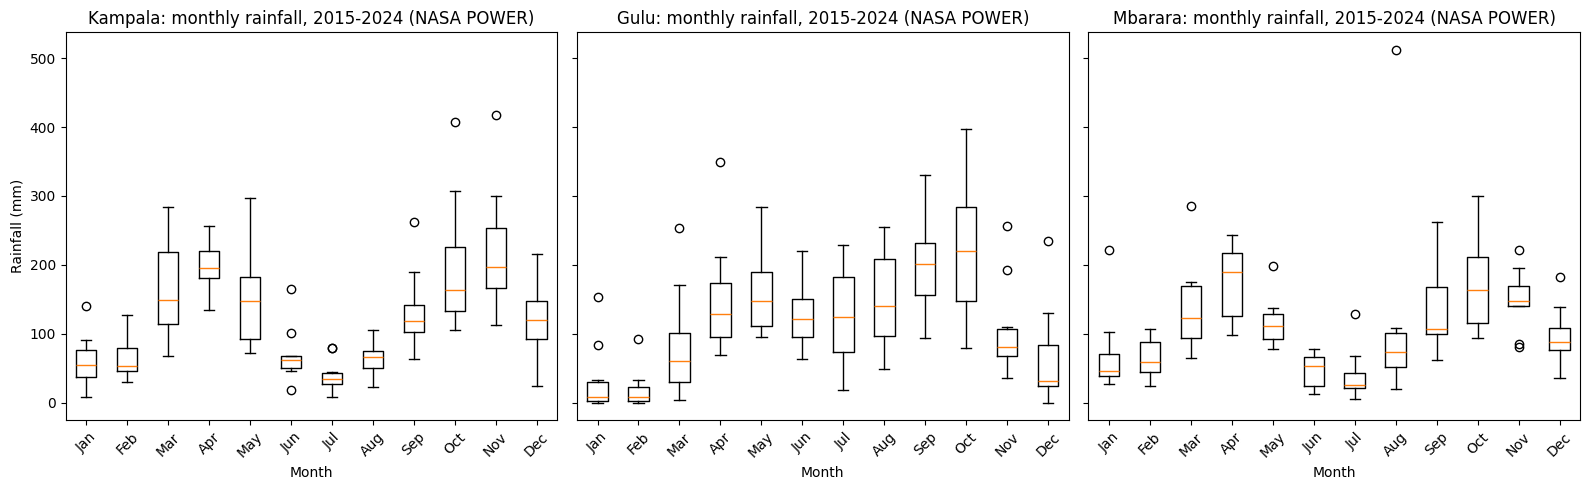

In [8]:
nasa_df = pd.read_csv("../data/rainfall_nasa_power_2015_2024.csv")
print(nasa_df.head())
print(f"\nYears covered: {nasa_df['year'].min()}-{nasa_df['year'].max()}, "
      f"regions: {sorted(nasa_df['region'].unique())}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, name in zip(axes, ["Kampala", "Gulu", "Mbarara"]):
    region_df = nasa_df[nasa_df["region"] == name]
    monthly_values = [region_df[region_df["month"] == m]["rainfall_mm"].values for m in range(1, 13)]
    ax.boxplot(monthly_values, tick_labels=MONTHS)
    ax.set_title(f"{name}: monthly rainfall, 2015-2024 (NASA POWER)")
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

## Findings & Limitations

The corrected `cosine_similarity` function matched `scipy.spatial.distance.cosine` exactly (0.7866 for Kampala vs Gulu), confirming the fix from last year's `math.cos()` bug. The similarity matrices show why relying on cosine similarity alone is risky: all three region pairs scored "similar" by cosine (0.75-0.89), yet their Pearson correlations were weak or even negative (as low as -0.174 for Gulu-Mbarara) - cosine similarity was picking up on broadly overlapping rainfall *scale*, not necessarily a matching wet/dry *rhythm*, which Euclidean distance and correlation expose more clearly. Peak detection on the illustrative data classified Kampala as unimodal and Gulu/Mbarara as bimodal - the opposite of Uganda's well-known climate zones (Lake Victoria basin including Kampala is normally bimodal; northern Uganda including Gulu is normally closer to unimodal). This mismatch is a useful, honest finding: the assignment's illustrative monthly figures do not actually reproduce real Ugandan seasonality. Reassuringly, the real NASA POWER data used in the extension does show the expected pattern - Kampala's 10-year box plots show two visible rainfall peaks (around April and October-November), while Gulu shows one long wet season from roughly April to October - which is a strong argument for preferring the real dataset over the illustrative one for any real advisory decision.

**Limitations:** the core-task rainfall figures and crop thresholds are illustrative/simplified, not measured or officially cited values, so the crop suitability table and Gulu advisory note should be treated as a demonstration of method, not a validated agricultural recommendation. The NASA POWER data is satellite/reanalysis-derived (MERRA-2), not a ground station reading, and may differ somewhat from official UNMA records for the same towns.